In [7]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn
!pip install seaborn
!pip install split-folders

In [2]:
!curl -L -o ./brain-mri-images-for-brain-tumor-detection.zip https://www.kaggle.com/api/v1/datasets/download/navoneel/brain-mri-images-for-brain-tumor-detection

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 15.0M  100 15.0M    0     0  22.5M      0 --:--:-- --:--:-- --:--:-- 80.2M


In [4]:
!unzip ./brain-mri-images-for-brain-tumor-detection.zip -d ./raw-dataset

Archive:  ./brain-mri-images-for-brain-tumor-detection.zip
  inflating: ./raw-dataset/brain_tumor_dataset/no/1 no.jpeg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/10 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/11 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/12 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/13 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/14 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/15 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/17 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/18 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/19 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/2 no.jpeg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/20 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/21 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/22 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/23 no.jpg  
  inflating

In [5]:
!rm -rf ./raw-dataset/no
!rm -rf ./raw-dataset/yes

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score, classification_report, confusion_matrix


import splitfolders
import optuna
import numpy as np
import random

In [9]:
input_folder = "raw-dataset/brain_tumor_dataset"
output_folder = "dataset"

splitfolders.ratio(
  input=input_folder,
  output=output_folder,
  seed=32,
  ratio=(0.7, 0.2, 0.1)
)

Copying files: 253 files [00:00, 3780.17 files/s]


In [15]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE=16
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


In [19]:
def data_augmentation():
  # ============================================
  # IMAGE DATA GENERATOR
  # ===========================================

  train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,

  )

  validation_datagen = ImageDataGenerator(
    rescale=1./255,
  )

  # ============================================
  # LOAD IMAGE
  # ===========================================

  train_dir = "dataset/train"
  validation_dir = "dataset/val"
  test_dir = "dataset/test"

  train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
  )

  validation_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' ,
    shuffle=False,
    seed=SEED,
  )

  test_data = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED,
  )

  return train_data, validation_data, test_data


In [20]:
# ============================================
# OPTUNA OPTIMATION
# ===========================================
from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score

def objective(trial: optuna.Trial):
  model = tf.keras.models.Sequential()

  n_conv = trial.suggest_int('n_conv', 2, 4)
  lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
  n_dense = trial.suggest_int('n_dense', 1, 3)

  # INPUT CONV2D
  model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), padding='same'))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.MaxPooling2D())

  for i in range(n_conv):
    filters = trial.suggest_categorical(f'filters_{i}', [64, 128, 256])
    conv_dropout = trial.suggest_float(f'conv_droprate_{i}', 0.2, 0.4, step=0.05)
    model.add(tf.keras.layers.Conv2D(filters, (3, 3), activation='relu', padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Dropout(conv_dropout))

  # FULLY CONNECTED LAYERS
  model.add(tf.keras.layers.Flatten())
  for i in range(n_dense):
    dense_unit = trial.suggest_categorical(f'dense_unit_{i}', [128, 256, 512])
    dense_dropout = trial.suggest_float(f'dense_droprate_{i}', 0.2, 0.4, step=0.05)
    model.add(tf.keras.layers.Dense(dense_unit, activation='relu'))
    model.add(tf.keras.layers.Dropout(dense_dropout))

  # OUTPUT LAYER
  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=[
      'accuracy',
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.AUC(name='auc')
    ]
  )

  callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
  ]

  train_data, validation_data, test_data = data_augmentation()
  model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    callbacks=callbacks,
    verbose=0,
    batch_size=BATCH_SIZE,
  )

  # f1 score validation data
  validation_data.reset()
  y_prob = model.predict(validation_data).flatten()
  y_pred = (y_prob > 0.5).astype(int)
  y_true = validation_data.classes

  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)

  trial.set_user_attr('recall', recall)
  trial.set_user_attr('auc', auc)
  trial.set_user_attr('f1', f1)
  trial.set_user_attr('accuracy', accuracy)

  print("===============TRIAL======================")
  print(f"Trial Recall       : {recall}")
  print(f"Trial AUC          : {auc}")
  print(f"Trial F1           : {f1}")
  print(f"Trial Accuracy     : {accuracy}")

  scoring = 0.5 * recall + 0.4 * auc + 0.1 * accuracy
  return scoring

In [21]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================
study = optuna.create_study(direction='maximize', study_name='model-tunning')
study.optimize(objective,n_trials=20)
best_trial = study.best_trial
print("\n================ FINAL =====================")
print(f"Best Score        : {best_trial.value:.4f}")
print(f"Best AUC          : {best_trial.user_attrs['auc']:.4f}")
print(f"Best Recall       : {best_trial.user_attrs['recall']:.4f}")
print(f"Best F1           : {best_trial.user_attrs['f1']:.4f}")
print(f"Best Accuracy     : {best_trial.user_attrs['accuracy']:.4f}")
print(f"Best Params       : {best_trial.params}")

[I 2026-05-24 08:01:28,861] A new study created in memory with name: model-tunning
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step


[I 2026-05-24 08:02:18,879] Trial 0 finished with value: 0.33205772495755526 and parameters: {'n_conv': 3, 'learning_rate': 1.091379904404117e-05, 'n_dense': 3, 'filters_0': 256, 'conv_droprate_0': 0.30000000000000004, 'filters_1': 128, 'conv_droprate_1': 0.4, 'filters_2': 256, 'conv_droprate_2': 0.25, 'dense_unit_0': 256, 'dense_droprate_0': 0.25, 'dense_unit_1': 256, 'dense_droprate_1': 0.30000000000000004, 'dense_unit_2': 256, 'dense_droprate_2': 0.2}. Best is trial 0 with value: 0.33205772495755526.


===============TRIAL======================
Trial Recall       : 0.0
Trial AUC          : 0.735144312393888
Trial F1           : 0.0
Trial Accuracy     : 0.38
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

===============TRIAL======================
Trial Recall       : 0.0
Trial AUC          : 0.23938879456706286
Trial F1           : 0.0
Trial Accuracy     : 0.38


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step


[I 2026-05-24 08:21:59,823] Trial 19 finished with value: 0.23969779286926995 and parameters: {'n_conv': 4, 'learning_rate': 2.239031584230886e-05, 'n_dense': 2, 'filters_0': 256, 'conv_droprate_0': 0.2, 'filters_1': 128, 'conv_droprate_1': 0.35000000000000003, 'filters_2': 128, 'conv_droprate_2': 0.4, 'filters_3': 64, 'conv_droprate_3': 0.35000000000000003, 'dense_unit_0': 256, 'dense_droprate_0': 0.30000000000000004, 'dense_unit_1': 128, 'dense_droprate_1': 0.30000000000000004}. Best is trial 16 with value: 0.9514974533106962.


===============TRIAL======================
Trial Recall       : 0.0
Trial AUC          : 0.5042444821731749
Trial F1           : 0.0
Trial Accuracy     : 0.38

================ FINAL =====================
Best Score        : 0.9515
Best AUC          : 0.9491
Best Recall       : 0.9677
Best F1           : 0.9091
Best Accuracy     : 0.8800
Best Params       : {'n_conv': 4, 'learning_rate': 2.6520853395216863e-05, 'n_dense': 1, 'filters_0': 256, 'conv_droprate_0': 0.30000000000000004, 'filters_1': 128, 'conv_droprate_1': 0.2, 'filters_2': 128, 'conv_droprate_2': 0.4, 'filters_3': 128, 'conv_droprate_3': 0.4, 'dense_unit_0': 256, 'dense_droprate_0': 0.30000000000000004}


In [22]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# =========================================================

model = tf.keras.models.Sequential()
best_param = best_trial.params
# INPUT CONV2D
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

for i in range(best_param['n_conv']):
  model.add(tf.keras.layers.Conv2D(best_param[f'filters_{i}'], (3, 3), activation='relu', padding='same'))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.MaxPooling2D())
  model.add(tf.keras.layers.Dropout(best_param[f'conv_droprate_{i}']))

# FULLY CONNECTED LAYERS
model.add(tf.keras.layers.Flatten())
for i in range(best_param['n_dense']):
  model.add(tf.keras.layers.Dense(best_param[f'dense_unit_{i}'], activation='relu'))
  model.add(tf.keras.layers.Dropout(best_param[f'dense_droprate_{i}']))

# OUTPUT LAYER
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=best_param['learning_rate']),
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 112, 112, 256)  │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_91          │ (None, 112, 112, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_92          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_93          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_94 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_108 (Dropout)           │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_109 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,273,921 (8.67 MB)

 Trainable params: 2,272,577 (8.67 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [24]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='main'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

train_data, validation_data, test_data = data_augmentation()
history = model.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

# f1 score validation data
validation_data.reset()
y_prob = model.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:77: UserWarning: EarlyStopping mode 'main' is unknown, fallback to auto mode.
  super().__init__(monitor, mode, min_delta=min_delta)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - accuracy: 0.6136 - auc: 0.6698 - loss: 0.8978 - precision: 0.7000 - recall: 0.6481 - val_accuracy: 0.6200 - val_auc: 0.5484 - val_loss: 0.6640 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 3.3151e-06
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.6023 - auc: 0.6392 - loss: 0.9469 - precision: 0.6696 - recall: 0.6944 - val_accuracy: 0.6200 - val_auc: 0.5789 - val_loss: 0.6669 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 3.3151e-06
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.6250 - auc: 0.6169 - loss: 1.0262 - precision: 0.6810 - recall: 0.7315 - val_accuracy: 0.6200 - val_auc: 0.5628 - val_loss: 0.6728 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 3.3151e-06
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.6250 - auc: 0.6921 - loss: 0.8940 - precision: 0.7019 - recall: 0.6759 - val_accuracy: 0.6200 - val_auc: 0.5942 - val_lo

In [25]:
loss, accuracy, auc, precision, recall = model.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5926 - auc: 0.5568 - loss: 0.6785 - precision: 0.5926 - recall: 1.0000

Test Accuracy: 0.5925925970077515
Test Precision: 0.5925925970077515
Test Recall: 0.5568181872367859
Test AUC: 1.0
Test Loss: 0.6785054802894592


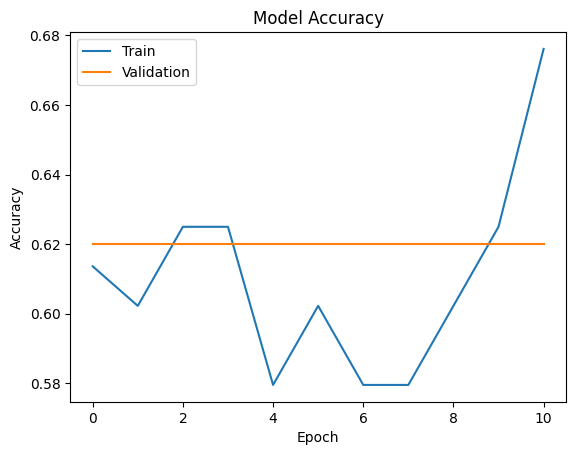

In [26]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

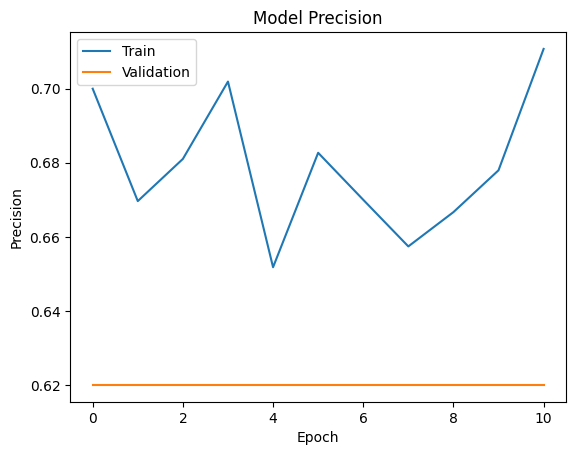

In [27]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

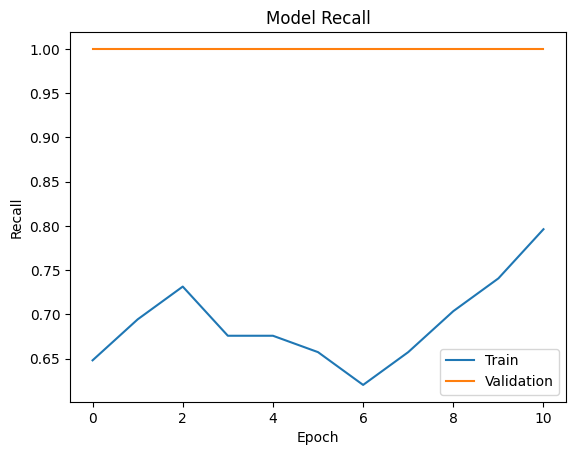

In [28]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

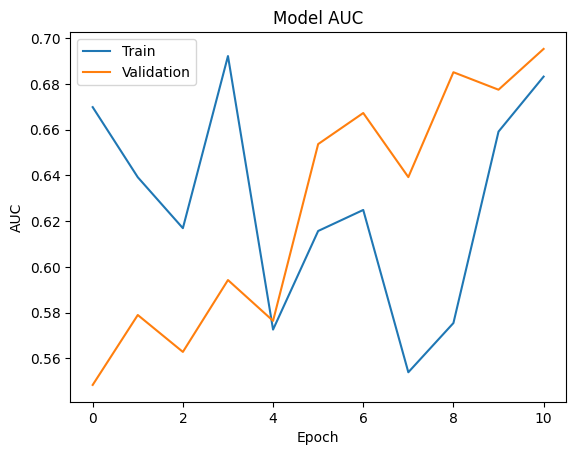

In [29]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

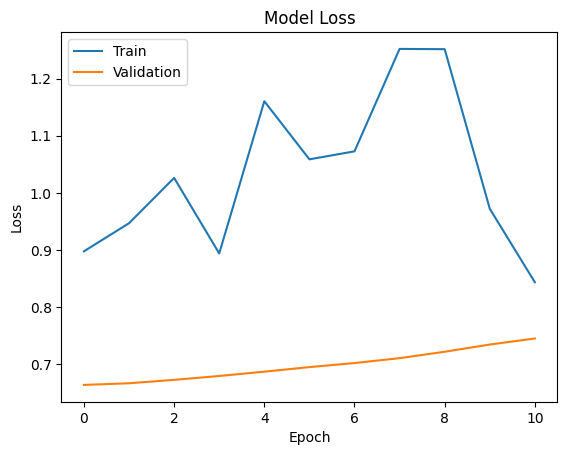

In [30]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [31]:
# =========================================================
# TEST METRIC
# =========================================================

test_data.reset()
y_prob = model.predict(test_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step

================ MODEL =====================
Model Recall       : 1.0
Model AUC          : 0.7215909090909091
Model F1           : 0.7441860465116279
Model Accuracy     : 0.5925925925925926


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


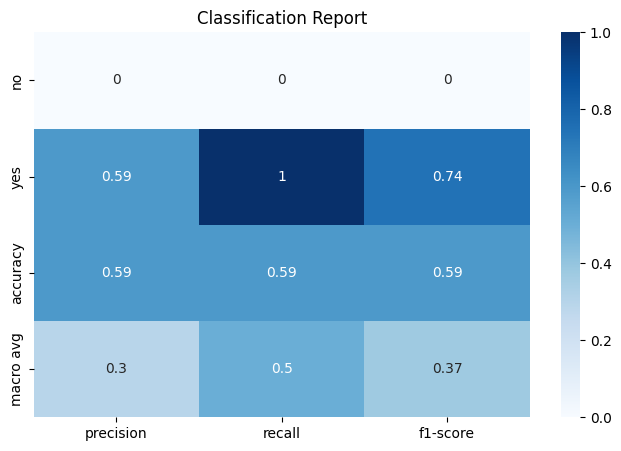

In [32]:
import pandas as pd
import seaborn as sns

class_names = list(train_data.class_indices.keys())
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_report.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Classification Report")
plt.show()

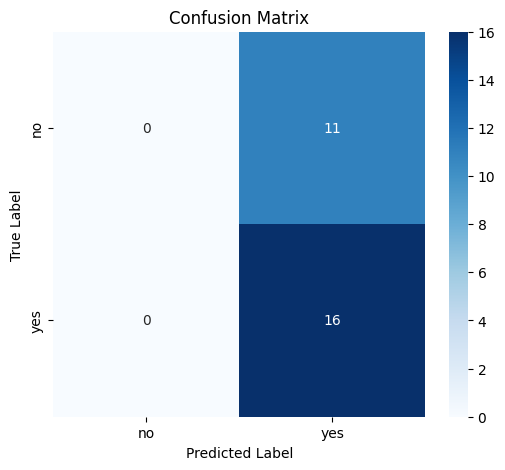

In [33]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()